In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [20]:
import pandas as pd

df = pd.read_csv('archive/flight_data.csv', index_col=0)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (300153, 11)

Columns: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

First 5 rows:
    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  

Data types:
airline   

In [21]:
# 2. EXPLORATORY DATA ANALYSIS

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


Saved: price_distribution.png


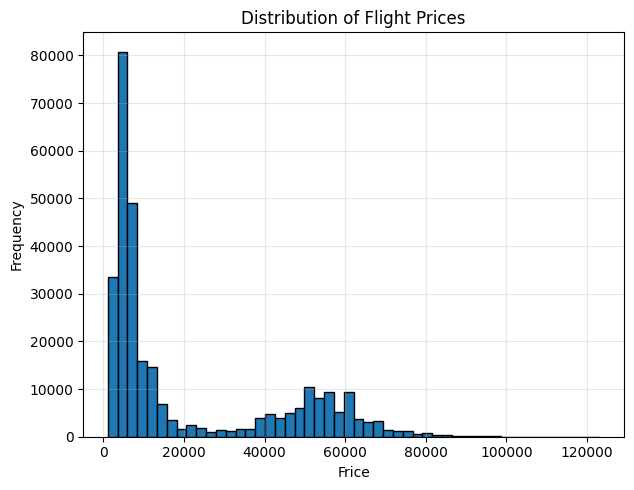

In [22]:
# Plot 1: Price distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, edgecolor='black')
plt.xlabel('Frice')
plt.ylabel('Frequency')
plt.title('Distribution of Flight Prices')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150)
print("Saved: price_distribution.png")

Saved: price_by_airline.png


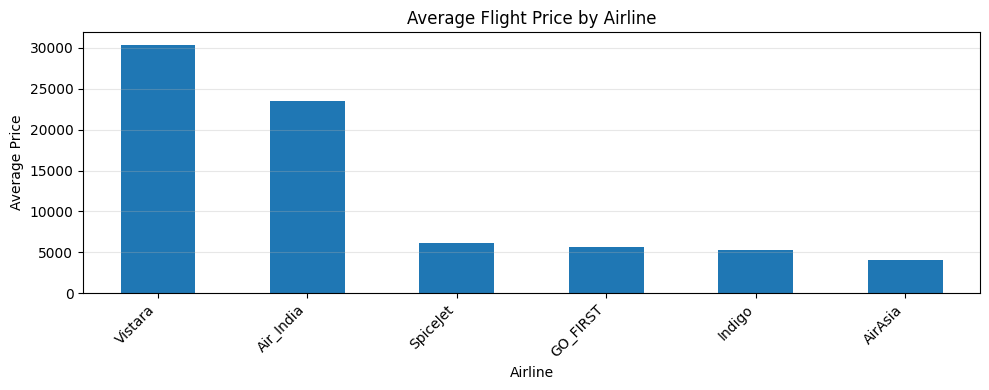

In [23]:
# Plot 2: Price by Airline
if 'airline' in df.columns:
    plt.figure(figsize=(10, 4))
    airline_prices = df.groupby('airline')['price'].mean().sort_values(ascending=False)
    airline_prices.plot(kind='bar')
    plt.xlabel('Airline')
    plt.ylabel('Average Price')
    plt.title('Average Flight Price by Airline')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('price_by_airline.png', dpi=150)
    print("Saved: price_by_airline.png")

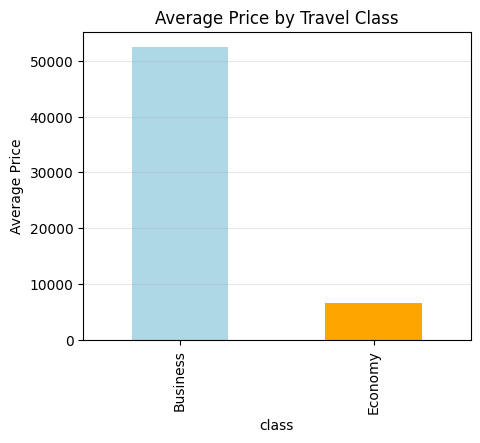

In [24]:
# Plot 3: Average price per class
plt.figure(figsize=(5,4))
df.groupby('class')['price'].mean().plot(kind='bar', color=['lightblue', 'orange'])
plt.title('Average Price by Travel Class')
plt.ylabel('Average Price')
plt.grid(alpha=0.3, axis='y')
plt.show()


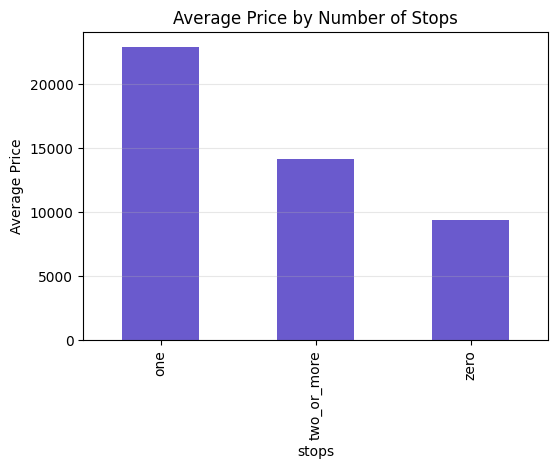

In [25]:
# Plot 4: Average price per number of stops
plt.figure(figsize=(6,4))
df.groupby('stops')['price'].mean().plot(kind='bar', color='slateblue')
plt.title('Average Price by Number of Stops')
plt.ylabel('Average Price')
plt.grid(alpha=0.3, axis='y')
plt.show()

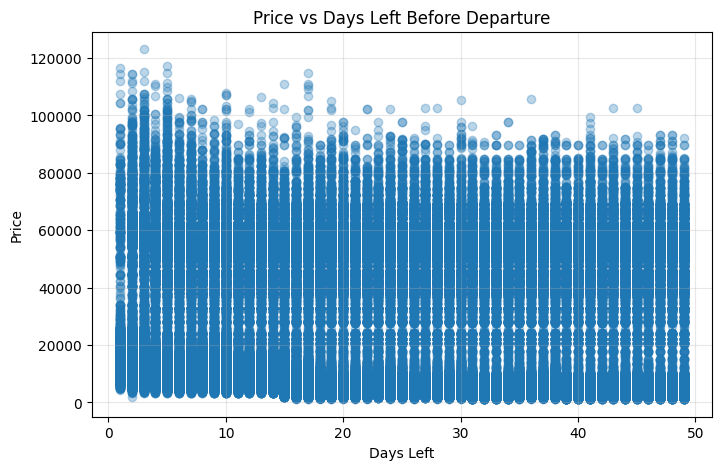

In [26]:
# Plot 5: Relationship between days_left and price
plt.figure(figsize=(8,5))
plt.scatter(df['days_left'], df['price'], alpha=0.3)
plt.title('Price vs Days Left Before Departure')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.show()

In [27]:
# 3. FEATURE ENGINEERING

In [28]:
df_processed = df.copy()

# Encode time of day
time_map = {
    'Late_Night': 0,
    'Night': 1,
    'Early_Morning': 2,
    'Morning': 3,
    'Afternoon': 4,
    'Evening': 5
}

for col in ['departure_time', 'arrival_time']:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].map(time_map)
        print(f"Mapped time of day in column: {col}")

Mapped time of day in column: departure_time
Mapped time of day in column: arrival_time


In [29]:
# Encode categorical features using LabelEncoder
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
if 'price' in categorical_cols:
    categorical_cols.remove('price')

print(f"\nCategorical columns to encode: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded: {col}")

# Fill missing values
df_processed = df_processed.fillna(0)

# Show resulting columns
print(f"\nProcessed dataset shape: {df_processed.shape}")
print(f"Columns: {list(df_processed.columns)}")


Categorical columns to encode: ['airline', 'flight', 'source_city', 'stops', 'destination_city', 'class']
Encoded: airline
Encoded: flight
Encoded: source_city
Encoded: stops
Encoded: destination_city
Encoded: class

Processed dataset shape: (300153, 11)
Columns: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [30]:
# Separate features and target
X = df_processed.drop('price', axis=1)
y = df_processed['price']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")


Features shape: (300153, 10)
Target shape: (300153,)

Features: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left']



Basic correlation analysis (numeric features):
price               1.000000
flight              0.305872
airline             0.243358
duration            0.204222
arrival_time        0.053395
destination_city    0.004795
source_city         0.004594
departure_time     -0.022571
days_left          -0.091949
stops              -0.202620
Name: price, dtype: float64


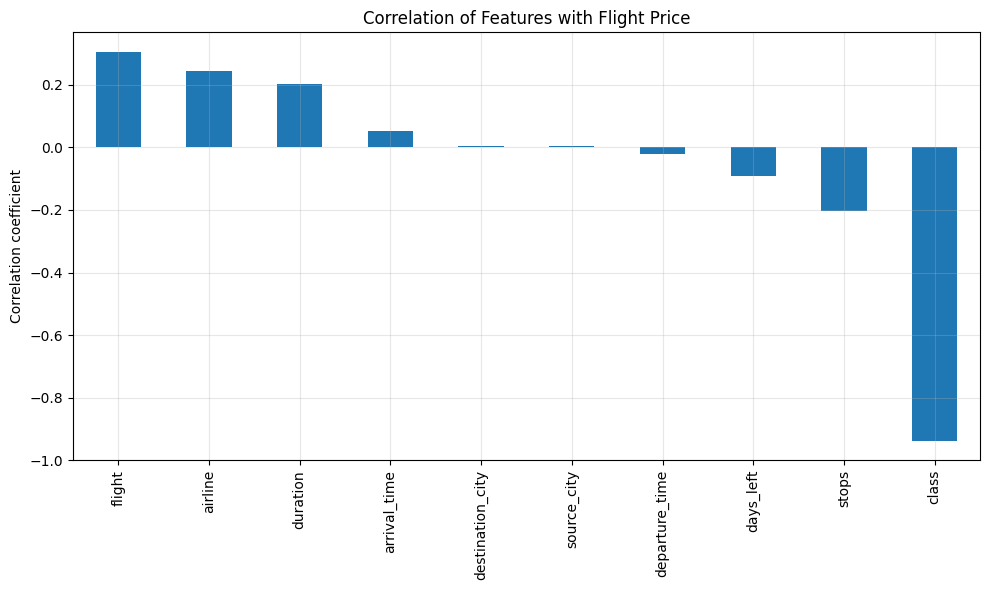

In [31]:
print("\nBasic correlation analysis (numeric features):")
corr = df_processed.corr()['price'].sort_values(ascending=False)
print(corr.head(10))

plt.figure(figsize=(10, 6))
corr.drop('price').plot(kind='bar')
plt.title("Correlation of Features with Flight Price")
plt.ylabel("Correlation coefficient")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# 4. PREPARE DATA FOR MODELING

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 60% train, 20% validation, 20% test
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=1,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=1,
    shuffle=True
)

print(f"\nTrain set:      {len(X_train_full)} samples ({len(X_train_full)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_full)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


Train set:      180091 samples (60.0%)
Validation set: 60031 samples (20.0%)
Test set:       60031 samples (20.0%)

Feature scaling completed.


In [34]:
# 5. MODEL TRAINING

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb

models = {}

def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    train_mae = mean_absolute_error(y_train, y_pred_train)
    val_mae   = mean_absolute_error(y_val, y_pred_val)
    val_rmse  = np.sqrt(mean_squared_error(y_val, y_pred_val))
    val_r2    = r2_score(y_val, y_pred_val)

    print(f"\n{name}:")
    print(f"  Train MAE {train_mae:.2f}")
    print(f"  Val   MAE {val_mae:.2f} | RMSE {val_rmse:.2f} | R² {val_r2:.3f}")

    return {"model": model, "val_mae": val_mae, "val_r2": val_r2}


models["Linear Regression"] = evaluate_model(
    "Linear Regression", LinearRegression(),
    X_train_scaled, y_train_full,
    X_val_scaled, y_val
)

models["Ridge Regression"] = evaluate_model(
    "Ridge Regression", Ridge(alpha=1.0, random_state=1),
    X_train_scaled, y_train_full,
    X_val_scaled, y_val
)

models["Random Forest"] = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=1, n_jobs=-1),
    X_train_full, y_train_full,
    X_val, y_val
)

models["Gradient Boosting"] = evaluate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=1),
    X_train_full, y_train_full,
    X_val, y_val
)

models["XGBoost"] = evaluate_model(
    "XGBoost",
    xgb.XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.1, random_state=1, n_jobs=-1),
    X_train_full, y_train_full,
    X_val, y_val
)



Linear Regression:
  Train MAE 4654.01
  Val   MAE 4615.83 | RMSE 6977.78 | R² 0.905

Ridge Regression:
  Train MAE 4654.02
  Val   MAE 4615.84 | RMSE 6977.78 | R² 0.905

Random Forest:
  Train MAE 1079.24
  Val   MAE 1272.91 | RMSE 2613.89 | R² 0.987

Gradient Boosting:
  Train MAE 1993.32
  Val   MAE 1985.09 | RMSE 3477.88 | R² 0.976

XGBoost:
  Train MAE 1391.17
  Val   MAE 1461.13 | RMSE 2669.64 | R² 0.986



Model comparison:
            Model     Val MAE   Val R²
    Random Forest 1272.907222 0.986670
          XGBoost 1461.130981 0.986095
Gradient Boosting 1985.093179 0.976401
Linear Regression 4615.834310 0.905006
 Ridge Regression 4615.843475 0.905006


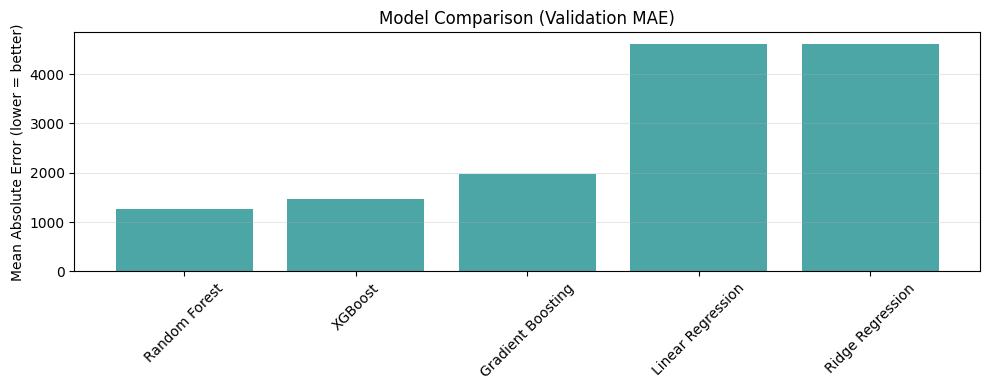


Best model based on validation MAE: Random Forest

Test Set Results (Random Forest):
  MAE:  1265.78
  RMSE: 2583.90
  R²:   0.987


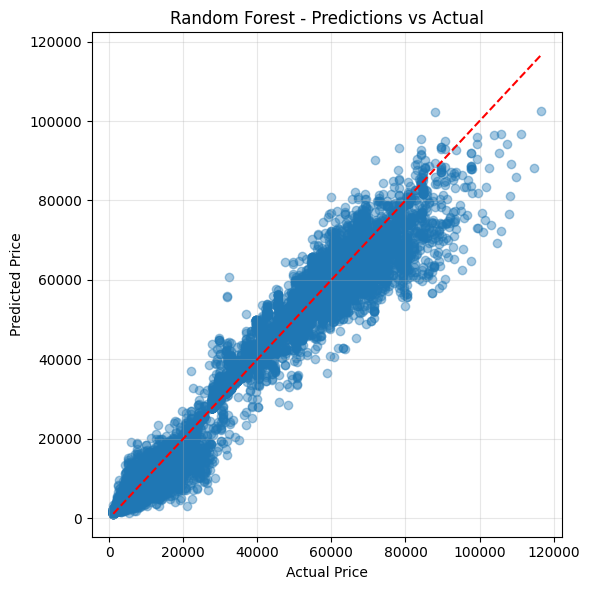

In [35]:
# 6. MODEL COMPARISON & FINAL EVALUATION

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Val MAE': [models[m]['val_mae'] for m in models],
    'Val R²': [models[m]['val_r2'] for m in models]
}).sort_values('Val MAE')

print("\nModel comparison:")
print(comparison_df.to_string(index=False))


plt.figure(figsize=(10,4))
plt.bar(comparison_df['Model'], comparison_df['Val MAE'], color='teal', alpha=0.7)
plt.title('Model Comparison (Validation MAE)')
plt.ylabel('Mean Absolute Error (lower = better)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]['model']
print(f"\nBest model based on validation MAE: {best_model_name}")

if best_model_name in ['Linear Regression', 'Ridge Regression']:
    X_test_final = X_test_scaled
else:
    X_test_final = X_test

y_pred_test = best_model.predict(X_test_final)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nTest Set Results ({best_model_name}):")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.3f}")

# Scatter-plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'{best_model_name} - Predictions vs Actual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Top 10 most important features:
         feature  importance
           class    0.888221
        duration    0.045900
          flight    0.028604
       days_left    0.013895
destination_city    0.009791
     source_city    0.006604
           stops    0.002021
    arrival_time    0.002014
  departure_time    0.001949
         airline    0.001000


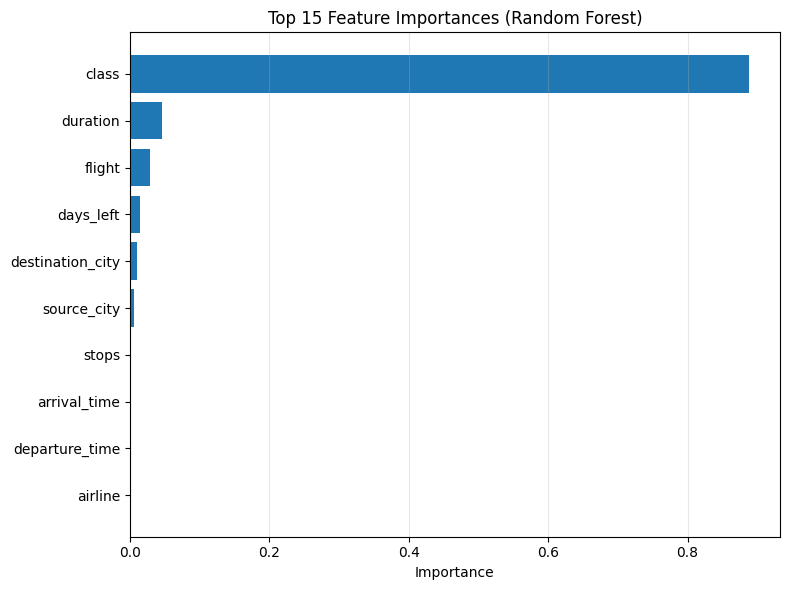

In [36]:
# 7. FEATURE IMPORTANCE

import pandas as pd
import matplotlib.pyplot as plt

if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 most important features:")
    print(feature_importance.head(10).to_string(index=False))

    # График важности признаков (top-15)
    top_n = 15
    top_features = feature_importance.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances ({best_model_name})")
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print(f"Model {best_model_name} does not provide feature_importances_.")
    print("Try using a tree-based model (RandomForest / GradientBoosting / XGBoost) for this plot.")


In [37]:
# 8. SAVING MODEL AND PREPROCESSING OBJECTS

import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Saved: model.pkl")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved: scaler.pkl")

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Saved: label_encoders.pkl")

with open('features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print("Saved: features.pkl")

model_info = {
    "model_name": best_model_name,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_r2": test_r2,
    "train_samples": len(X_train_full),
    "val_samples": len(X_val),
    "test_samples": len(X_test)
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("Saved: model_info.pkl")

print("\nAll objects successfully saved.")


Saved: model.pkl
Saved: scaler.pkl
Saved: label_encoders.pkl
Saved: features.pkl
Saved: model_info.pkl

All objects successfully saved.


In [39]:
# 9. NOTEBOOK COMPLETED / NEXT STEPS

print("\n" + "="*70)
print("9. NOTEBOOK COMPLETED / NEXT STEPS")
print("="*70)

print(f"\nBest Model: {best_model_name}")
print(f"Test MAE:  {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²:   {test_r2:.3f}")

print(f"\nOn average, predictions differ from actual prices by ±{test_mae:.0f} currency units.")
print(f"The model explains approximately {test_r2*100:.1f}% of the variance in flight prices.")


print("\nProject completed successfully")



9. NOTEBOOK COMPLETED / NEXT STEPS

Best Model: Random Forest
Test MAE:  1265.78
Test RMSE: 2583.90
Test R²:   0.987

On average, predictions differ from actual prices by ±1266 currency units.
The model explains approximately 98.7% of the variance in flight prices.

Project completed successfully
